# Segmentação de Clientes em Risco

Agrupa clientes flagged pelo modelo de churn (NB04) em perfis acionáveis via K-Means,
com Elbow/Silhouette para escolha de K, DBSCAN como comparativo e exportação para o NB06.

## 1. Importações e carregamento

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
K_NEGOCIO = 3
CORES_CLUSTERS = {0: '#2E86AB', 1: '#E84855', 2: '#F6AE2D'}

ROOT = Path('..')
PROCESSED_DIR = ROOT / 'data/processed'
MODELS_DIR = ROOT / 'models'

COLS_EXCLUIR_CLUSTER = [
    'customerID', 'Churn', 'prob_churn', 'predicao_churn', 'em_risco',
    'Contract', 'InternetService', 'PaymentMethod',
    'MonthlyCharges_orig', 'TotalCharges_orig', 'tenure_orig',
]

clientes = pd.read_parquet(PROCESSED_DIR / 'clientes_em_risco.parquet')
artefato_churn = joblib.load(MODELS_DIR / 'modelo_churn.pkl')
feature_cols = artefato_churn['feature_cols']

n_total = len(clientes)
n_churn_real = clientes['Churn'].sum()
fatura_media = clientes['MonthlyCharges_orig'].mean()

print(f'Clientes em risco: {n_total:,}')
print(f'Churn real entre flagged: {n_churn_real:,} ({n_churn_real / n_total * 100:.1f}%)')
print(f'Fatura mensal média (R$): {fatura_media:.2f}')
print(f'Features do modelo (NB04): {len(feature_cols)}')

Clientes em risco: 1,556
Churn real entre flagged: 1,082 (69.5%)
Fatura mensal média (R$): 79.28
Features do modelo (NB04): 47


## 2. Preparação das features para clustering

Utiliza as mesmas features do modelo de churn (já normalizadas no NB03), excluindo metadados de negócio.

In [2]:
cols_cluster = [c for c in feature_cols if c in clientes.columns]
X_cluster = clientes[cols_cluster].copy()

assert len(cols_cluster) == len(feature_cols), (
    f'Features ausentes no parquet: {set(feature_cols) - set(cols_cluster)}'
)
assert X_cluster.select_dtypes(include=['object', 'bool']).empty, (
    'Existem colunas não numéricas nas features de clustering.'
)

print(f'Features para clustering: {len(cols_cluster)}')
print(f'Matriz: {X_cluster.shape[0]:,} clientes × {X_cluster.shape[1]} features')

Features para clustering: 47
Matriz: 1,556 clientes × 47 features


## 3. Escolha do número de clusters

Elbow Method e Silhouette Score para K de 2 a 10. **K=3 é adotado por critério de negócio** — três perfis distintos são mais acionáveis para a equipe comercial do que dois grupos genéricos (ex.: alto/baixo risco), mesmo que o Silhouette sugira outro K.

K sugerido pelo Silhouette Score: 3 (score = 0.2829)
K adotado por critério de negócio: 3


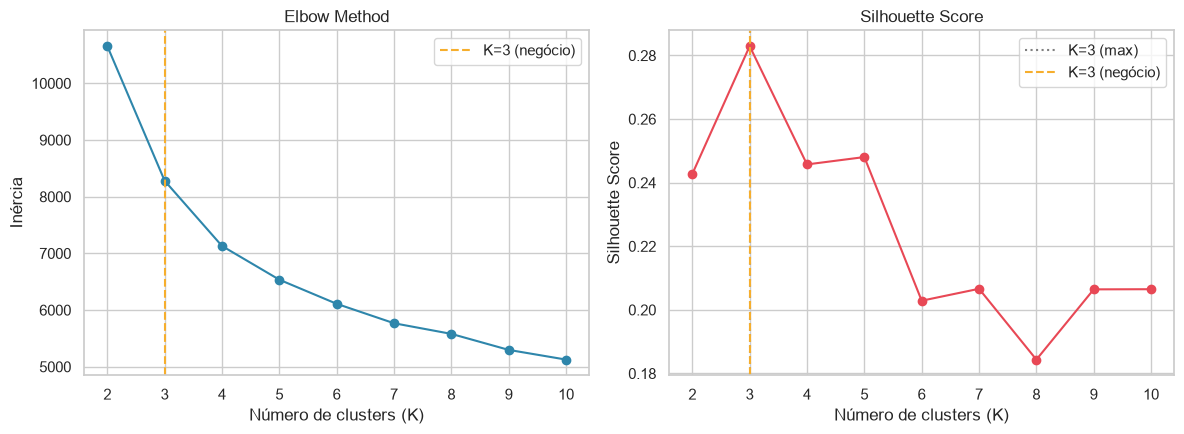

In [3]:
K_range = range(2, 11)
inercias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

k_silhouette = list(K_range)[int(np.argmax(silhouettes))]
print(f'K sugerido pelo Silhouette Score: {k_silhouette} (score = {max(silhouettes):.4f})')
print(f'K adotado por critério de negócio: {K_NEGOCIO}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(K_range), inercias, marker='o', color='#2E86AB')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Elbow Method')
axes[0].axvline(K_NEGOCIO, color='#F6AE2D', linestyle='--', label=f'K={K_NEGOCIO} (negócio)')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, marker='o', color='#E84855')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(k_silhouette, color='gray', linestyle=':', label=f'K={k_silhouette} (max)')
axes[1].axvline(K_NEGOCIO, color='#F6AE2D', linestyle='--', label=f'K={K_NEGOCIO} (negócio)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. K-Means final com K=3

In [4]:
kmeans = KMeans(n_clusters=K_NEGOCIO, random_state=RANDOM_STATE, n_init=10)
clientes['cluster'] = kmeans.fit_predict(X_cluster)

dist = clientes['cluster'].value_counts().sort_index()
print('Distribuição por cluster:')
for c, n in dist.items():
    print(f'  Cluster {c}: {n:,} clientes ({n / len(clientes) * 100:.1f}%)')

Distribuição por cluster:
  Cluster 0: 241 clientes (15.5%)
  Cluster 1: 427 clientes (27.4%)
  Cluster 2: 888 clientes (57.1%)


## 5. DBSCAN como comparativo

In [5]:
pca_dbscan = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca10 = pca_dbscan.fit_transform(X_cluster)

dbscan = DBSCAN(eps=3.0, min_samples=10)
labels_db = dbscan.fit_predict(X_pca10)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido = (labels_db == -1).sum()

print(f'DBSCAN (eps=3.0, min_samples=10, PCA=10):')
print(f'  Clusters encontrados: {n_clusters_db}')
print(f'  Pontos de ruído (label=-1): {n_ruido:,} ({n_ruido / len(clientes) * 100:.1f}%)')
print(
    '\nK-Means mantido: produz exatamente K=3 segmentos mutuamente exclusivos e '
    'interpretáveis, sem clientes órfãos (ruído). DBSCAN tende a fragmentar ou '
    'classificar grande parte como outliers — pouco acionável para campanhas de retenção.'
)

DBSCAN (eps=3.0, min_samples=10, PCA=10):
  Clusters encontrados: 1
  Pontos de ruído (label=-1): 0 (0.0%)

K-Means mantido: produz exatamente K=3 segmentos mutuamente exclusivos e interpretáveis, sem clientes órfãos (ruído). DBSCAN tende a fragmentar ou classificar grande parte como outliers — pouco acionável para campanhas de retenção.


## 6. Visualização PCA 2D

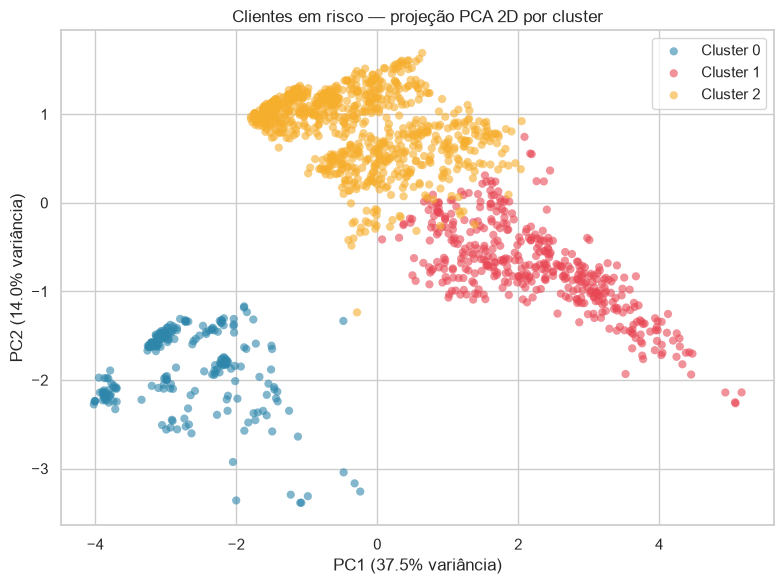

Variância explicada total (2 PCs): 51.5%


In [6]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_cluster)
var = pca_2d.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(clientes['cluster'].unique()):
    mask = clientes['cluster'] == c
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=CORES_CLUSTERS[c], label=f'Cluster {c}', alpha=0.6, s=35, edgecolors='none',
    )
ax.set_xlabel(f'PC1 ({var[0] * 100:.1f}% variância)')
ax.set_ylabel(f'PC2 ({var[1] * 100:.1f}% variância)')
ax.set_title('Clientes em risco — projeção PCA 2D por cluster')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Variância explicada total (2 PCs): {(var[0] + var[1]) * 100:.1f}%')

## 7. Perfil médio por cluster

Perfil médio por cluster:


cluster,0,1,2
tenure_orig,2.726,26.724,4.801
MonthlyCharges_orig,42.471,94.543,81.933
is_novo_cliente,0.942,0.016,0.976
fibra_sem_suporte,0.000,0.859,0.918
sem_protecao,0.730,0.379,0.628
qtd_servicos_protecao,-0.689,-0.140,-0.542
qtd_servicos,-0.723,0.259,-0.439
score_risco_estendido,0.615,1.361,1.213
prob_churn,0.850,0.848,0.905
Churn,0.656,0.665,0.721


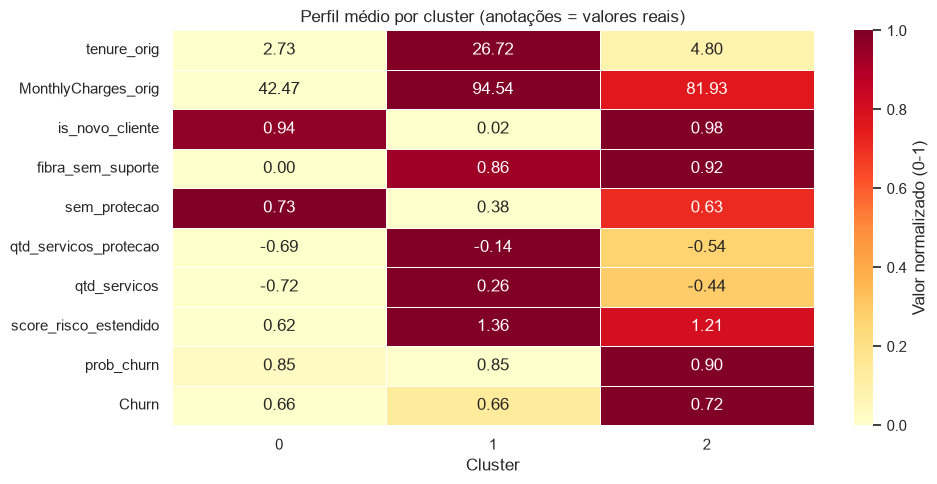

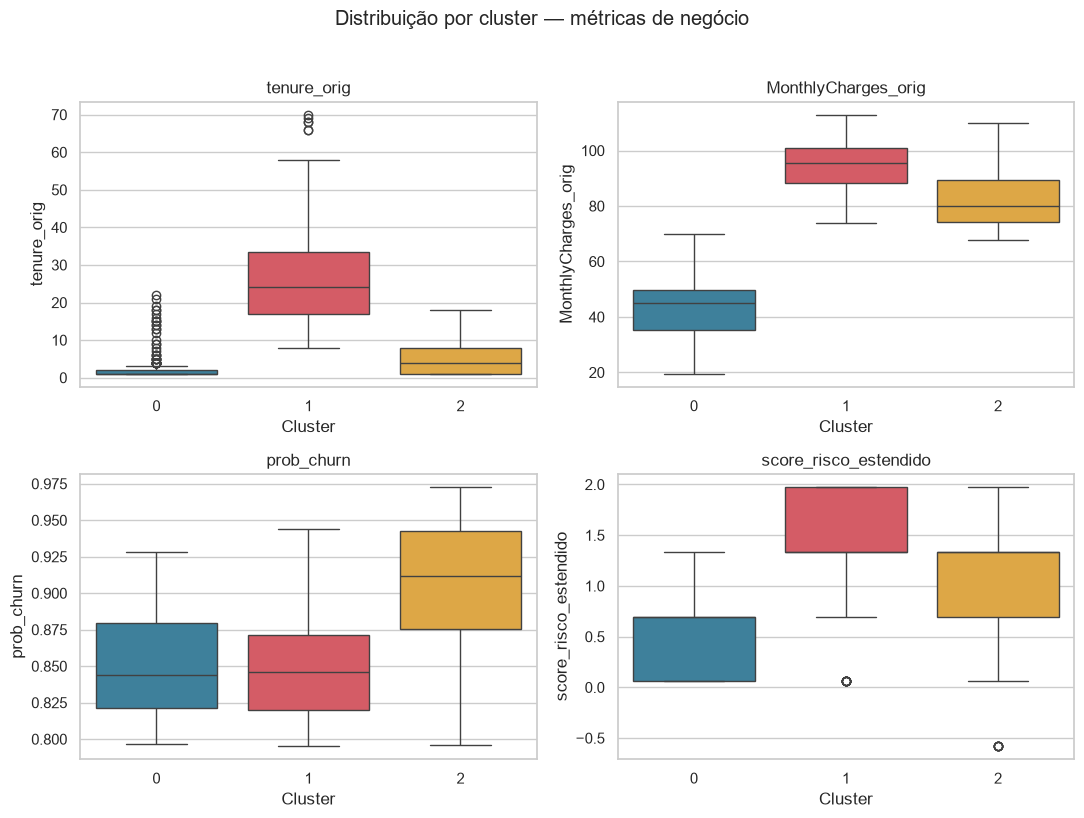

In [7]:
cols_perfil = [
    'tenure_orig', 'MonthlyCharges_orig', 'is_novo_cliente', 'fibra_sem_suporte',
    'sem_protecao', 'qtd_servicos_protecao', 'qtd_servicos', 'score_risco_estendido',
    'prob_churn', 'Churn',
]

perfil = clientes.groupby('cluster')[cols_perfil].mean()
perfil['n_clientes'] = clientes.groupby('cluster').size()
perfil = perfil.round(3)

print('Perfil médio por cluster:')
display(perfil.T)

# Heatmap: normalização só para cores, valores reais anotados
perfil_plot = perfil.drop(columns='n_clientes')
perfil_norm = (perfil_plot - perfil_plot.min()) / (perfil_plot.max() - perfil_plot.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    perfil_norm.T,
    annot=perfil_plot.T.round(2),
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Valor normalizado (0-1)'},
    ax=ax,
)
ax.set_title('Perfil médio por cluster (anotações = valores reais)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Boxplots das métricas-chave
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
box_cols = ['tenure_orig', 'MonthlyCharges_orig', 'prob_churn', 'score_risco_estendido']
for ax, col in zip(axes.ravel(), box_cols):
    sns.boxplot(
        data=clientes, x='cluster', y=col, ax=ax,
        palette=CORES_CLUSTERS, hue='cluster', legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel('Cluster')
plt.suptitle('Distribuição por cluster — métricas de negócio', y=1.02)
plt.tight_layout()
plt.show()

## 8. Exportação

In [8]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

saida_parquet = PROCESSED_DIR / 'clientes_segmentados.parquet'
saida_modelo = MODELS_DIR / 'kmeans_segmentacao.pkl'

clientes.to_parquet(saida_parquet, index=False)

artefato_kmeans = {
    'modelo': kmeans,
    'n_clusters': K_NEGOCIO,
    'feature_cols': cols_cluster,
    'random_state': RANDOM_STATE,
    'silhouette_k3': silhouette_score(X_cluster, clientes['cluster']),
    'k_silhouette_sugerido': k_silhouette,
}
joblib.dump(artefato_kmeans, saida_modelo)

print('Artefatos exportados:')
print(f'  {saida_parquet}')
print(f'    → {len(clientes):,} clientes x {clientes.shape[1]} colunas')
print(f'  {saida_modelo}')
print('\nSegmentação (Notebook 05) processada com sucesso!')

Artefatos exportados:
  ..\data\processed\clientes_segmentados.parquet
    → 1,556 clientes x 59 colunas
  ..\models\kmeans_segmentacao.pkl

Segmentação (Notebook 05) processada com sucesso!
